## **Setup**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]  # notebooks/ is one level down
sys.path.append(str(PROJECT_ROOT / "src"))

In [3]:
import os as os
import json as json
import time
import math
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import copy
import matplotlib.pyplot as plt

# Local
from chatGnT.config import CFG, ensure_dirs
from chatGnT.data import load, preprocess, tokenize, dataloaders
from chatGnT.models import train, evaluate, predict
import chatGnT.utils as utils

ensure_dirs(CFG)

/Users/slacksa/miniconda3/envs/chatGnT/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **Load & Clean Data**

In [4]:
data = load.load_all()
df = data["ingred"]
df_clean = preprocess.clean_recipes(df)
df_clean_filt = preprocess.filter_recipes(df_clean)


## **Make Vocab & Tokenize**

In [5]:

tokens = tokenize.recipe_to_tokens_mt(df_clean_filt)
print(tokens[0:2])


[[('<amt>1 oz</amt>', '<ingred>coconut-rum</ingred>'), ('<amt>0.5 oz</amt>', '<ingred>amaretto</ingred>'), ('<amt>4 oz</amt>', '<ingred>orange-juice</ingred>'), ('<amt>0.5 oz</amt>', '<ingred>grenadine</ingred>')], [('<amt>2 oz</amt>', '<ingred>light-rum</ingred>'), ('<amt>4 oz</amt>', '<ingred>ginger-beer</ingred>'), ('<amt>1 twist</amt>', '<ingred>lemon-peel</ingred>')]]


In [6]:
vocab_amt, vocab_ingred = tokenize.make_vocab_mt(tokens)
inv_vocab_amt, inv_vocab_ingred = tokenize.invert_vocab_mt(vocab_amt, vocab_ingred)
tokens_padded = tokenize.embed_tokens_mt(tokens, vocab_amt, vocab_ingred)


In [7]:
# Check vocab and padded tokens
print("Vocabulary:", vocab_amt)
print("Vocabulary:", vocab_ingred)
print("Padded Tokens:", tokens_padded[0:2])

Vocabulary: {'<amt>0.125 l</amt>': 1, '<amt>0.125 shot</amt>': 2, '<amt>0.125 tsp</amt>': 3, '<amt>0.16666666666666666 glass</amt>': 4, '<amt>0.2 part</amt>': 5, '<amt>0.25 cl</amt>': 6, '<amt>0.25 cup</amt>': 7, '<amt>0.25 glass</amt>': 8, '<amt>0.25 oz</amt>': 9, '<amt>0.25 part</amt>': 10, '<amt>0.25 shot</amt>': 11, '<amt>0.25 tsp</amt>': 12, '<amt>0.25</amt>': 13, '<amt>0.3333333333333333 cup</amt>': 14, '<amt>0.3333333333333333 oz</amt>': 15, '<amt>0.3333333333333333 part</amt>': 16, '<amt>0.3333333333333333 shot</amt>': 17, '<amt>0.4 part</amt>': 18, '<amt>0.5 can</amt>': 19, '<amt>0.5 cup</amt>': 20, '<amt>0.5 gal</amt>': 21, '<amt>0.5 glass</amt>': 22, '<amt>0.5 jigger</amt>': 23, '<amt>0.5 kg</amt>': 24, '<amt>0.5 l</amt>': 25, '<amt>0.5 lb</amt>': 26, '<amt>0.5 oz</amt>': 27, '<amt>0.5 part</amt>': 28, '<amt>0.5 piece</amt>': 29, '<amt>0.5 pint</amt>': 30, '<amt>0.5 shot</amt>': 31, '<amt>0.5 slice</amt>': 32, '<amt>0.5 tsp</amt>': 33, '<amt>0.5</amt>': 34, '<amt>0.666666666

In [8]:
amt_seqs, ingred_seqs = zip(*tokens_padded)  # unzip into two lists

# Convert to tensors
amt_tensor = torch.tensor(amt_seqs, dtype=torch.long)     # shape: (num_recipes, seq_len)
ingred_tensor = torch.tensor(ingred_seqs, dtype=torch.long)  # shape: (num_recipes, seq_len)

print(amt_tensor.shape, ingred_tensor.shape)

torch.Size([596, 13]) torch.Size([596, 13])


## **Get Batches**

In [9]:
train_loader, val_loader = dataloaders.make_dataloaders_mt(amt_tensor, ingred_tensor)

## **Train Model**

In [10]:
config = {
    # model architecture
    "ntoken_amt": len(vocab_amt),
    "ntoken_ingred": len(vocab_ingred),
    "ninp": 16,  # embed size
    "nhead": 4,
    "nhid": 256,
    "nlayers":2,
    "model_version": "multi_task",

    # training setup
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "scheduler_gamma": 0.95,
    "scheduler_step_size": 1,

    # token details
    "pad_id_amt": vocab_amt["<pad>"],
    "pad_id_ingred": vocab_ingred["<pad>"],

    # epochs, early stopping, & logs
    "epochs": 10000,
    "early_stop": 100,
    "log_interval": 6
}


In [11]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = train.build_model(config, device)  # what model network is
optimizer = train.build_optimizer(model, config)  # how model learns
scheduler = train.build_scheduler(optimizer, config)  # how learning changes over time
criterion_amt = torch.nn.CrossEntropyLoss(ignore_index=config["pad_id_amt"])
criterion_ingred = torch.nn.CrossEntropyLoss(ignore_index=config["pad_id_ingred"])

/Users/slacksa/repos/chatGnT/src/chatGnT/models/transformer.py:57: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = TransformerEncoder(encoder_layers, nlayers)


In [12]:
best_model, train_losses, val_losses, gradient_magnitudes = train.train_model_mt(
    model,
    train_loader,
    val_loader,
    device,
    optimizer,
    scheduler,
    criterion_amt,
    criterion_ingred,
    config
)

/Users/slacksa/miniconda3/envs/chatGnT/lib/python3.11/site-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


Epoch 1 | Batch 6 | LR 0.000100 | Loss 13.2467 | PPL 566183.99 | Time 0.10s
Epoch 1 | Batch 12 | LR 0.000100 | Loss 11.3322 | PPL 83466.58 | Time 0.05s
Epoch 1 | Batch 15 | LR 0.000100 | Loss 11.3435 | PPL 84417.96 | Time 0.03s
-----------------------------------------------------------------------------------------
Epoch 1 | Val Loss: 11.3325 | Time 0.18885517120361328 | Val PPL: 83494.83
-----------------------------------------------------------------------------------------
Epoch 2 | Batch 6 | LR 0.000095 | Loss 13.1932 | PPL 536700.93 | Time 0.06s
Epoch 2 | Batch 12 | LR 0.000095 | Loss 11.2819 | PPL 79371.33 | Time 0.05s
Epoch 2 | Batch 15 | LR 0.000095 | Loss 11.2883 | PPL 79881.40 | Time 0.03s
-----------------------------------------------------------------------------------------
Epoch 2 | Val Loss: 11.2697 | Time 0.1471419334411621 | Val PPL: 78406.82
-----------------------------------------------------------------------------------------
Epoch 3 | Batch 6 | LR 0.000090 | L

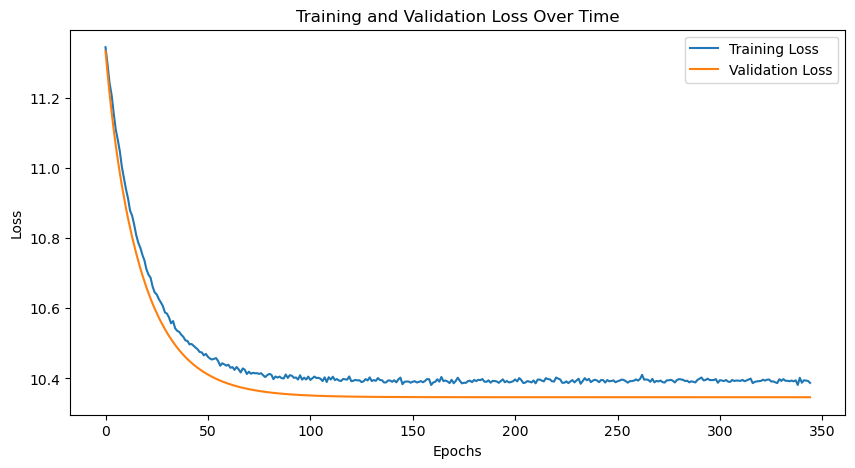

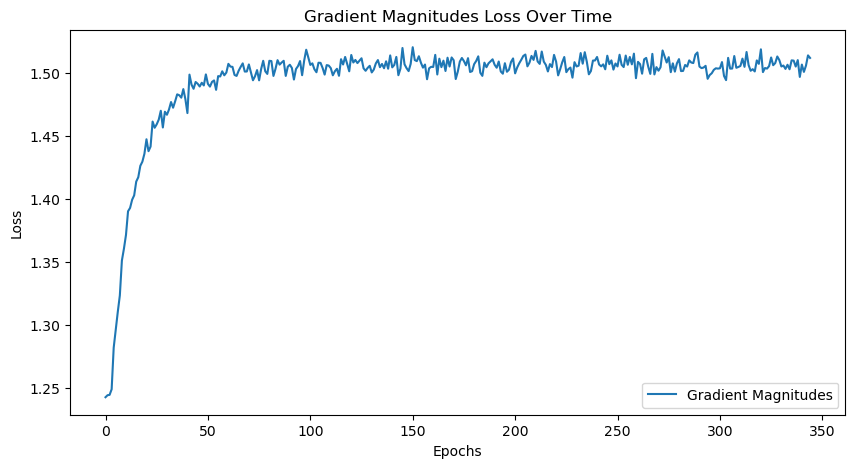

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.show()



plt.figure(figsize=(10, 5))
plt.plot(gradient_magnitudes, label='Gradient Magnitudes')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Gradient Magnitudes Loss Over Time')
plt.legend()
plt.show()


## **Save Model**

In [14]:
# TODO: make this a function

save_dir = "../outputs/models/multi_task"
os.makedirs(save_dir, exist_ok=True)

# Save metrics
metrics = {
    "train_loss": train_losses,
    "val_loss": val_losses,
}
with open(os.path.join(save_dir, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=4)

# Save model
torch.save({
    "model_state_dict": best_model.state_dict(),
    "config": {
        "ntoken_amt": config["ntoken_amt"],
        "ntoken_ingred": config["ntoken_ingred"],
        "ninp": config["ninp"],
        "nhead": config["nhead"],
        "nhid": config["nhid"],
        "nlayers": config["nlayers"],
    },
    "vocab_amt": vocab_amt,
    "vocab_ingred" : vocab_ingred
}, f"{save_dir}/model.pt")